# Introducción

En el presente documento haremos el análisis de un conjunto de datos llamado "German Credit data" que contiene información categórica y numérica de personas que tienen un crédito bancario. El conjunto de datos fue obtendio de (Dua, D., & Graff, C., s.f.).

In [184]:
# Importación de las librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import textwrap

#Módulos de Scikit-Learn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Obtención de los datos

El primero paso es obtener los datos en un formato legible. El dataset original tiene la siguiente forma:

Como podemos notar es un formato ilegible, sin embargo, toma sentido cuando agregamos los nombres de las columnas y traducimos cada código en una descripción. Para hacer dicha traducción haremos uso del documento de llamado "german.doc" que contiene la información necesaria. El siguiente script de python nos ayudará a hacer la traducción de los códigos a columnas más descriptivas:

In [43]:
# Creamos un dataframe vacío
columnas=["Status of existing checking account",
         "Duration in month",
         "Credit history",
         "Purpose",
         "Credit amount",
         "Savings account/bonds",
         "Present employment since",
         "Installment rate in percentage of disposable income",
         "Personal status and sex",
         "Other debtors/guarantors",
         "Present residence since",
         "Property",
         "Age in years",
         "Other installment plans",
         "Housing",
         "Number of existing credits at this bank",
         "Job",
         "Number of people being liable to provide maintenance for",
         "Telephone",
         "Foreign worker",
         "Risk"]
df = pd.DataFrame(columns=columnas)

# Leemos el dataset
with open("dataset/german.data", "r", encoding="utf-8") as archivo:
    for linea in archivo:
        renglon = linea.split(" ")
        renglon = [x.strip() for x in renglon]
        df_renglon = pd.DataFrame([renglon], columns=columnas)
        df = pd.concat([df, df_renglon])

# Definimos las reglas de traducción de códigos
df_1 = pd.DataFrame([["A11", "... < 0 DM"],
                    ["A12", "0 <= ... < 200 DM"],
                    ["A13", "... >= 200 DM/salary assignments for at least 1 year"],
                    ["A14", "no checking account"]],
                    columns=["Status of existing checking account","Valor"])
df_3 = pd.DataFrame([["A30","no credits taken/all credits paid back duly"],
                    ["A31","all credits at this bank paid back duly"],
                    ["A32","existing credits paid back duly till now"],
                    ["A33","delay in paying off in the past"],
                    ["A34", "critical account/other credits existing (not at this bank)"]],
                    columns=["Credit history","Valor"])
df_4 = pd.DataFrame([["A40", "car (new)"],
                    ["A41", "car (used)"],
                    ["A42", "furniture/equipment"],
                    ["A43", "radio/television"],
                    ["A44", "domestic appliances"],
                    ["A45", "repairs"],
                    ["A46", "education"],
                    ["A47", "(vacation - does not exist?)"],
                    ["A48", "retraining"],
                    ["A49", "business"],
                    ["A410", "others"]],
                    columns=["Purpose","Valor"]
                    )
df_6 = pd.DataFrame([["A61", "... < 100 DM"],
                    ["A62", "100 <= ... < 500 DM"],
                    ["A63", "500 <= ... < 1000 DM"],
                    ["A64", ".. >= 1000 DM"],
                    ["A65", "unknown/no savings account"]],
                   columns=["Savings account/bonds","Valor"])
df_7 = pd.DataFrame([["A71", "unemployed"],
                    ["A72", "... < 1 year"],
                    ["A73", "1 <= ... < 4 years"  ],
                    ["A74", "4 <= ... < 7 years"],
                    ["A75", "... >= 7 years"]],
                    columns=["Present employment since","Valor"])
df_9 = pd.DataFrame([["A91", "male: divorced/separated"],
                    ["A92", "female: divorced/separated/married"],
                    ["A93", "male: single"],
                    ["A94", "male: married/widowed"],
                    ["A95", "female: single"]],
                    columns=["Personal status and sex","Valor"])
df_10 = pd.DataFrame([["A101", "none"],
                    ["A102", "co-applicant"],
                    ["A103", "guarantor"]],
                    columns=["Other debtors/guarantors","Valor"])
df_12 = pd.DataFrame([["A121", "real estate"],
                    ["A122", "building society savings agreement/life insurance"],
                    ["A123", "car or other, not in attribute 6"],
                    ["A124", "unknown/no property"]],
                    columns=["Property","Valor"])
df_14 = pd.DataFrame([["A141", "bank"],
                    ["A142", "stores"],
                    ["A143", "none"]],
                    columns=["Other installment plans","Valor"])
df_15 = pd.DataFrame([["A151", "rent"],
                    ["A152", "own"],
                    ["A153", "for free"]],
                    columns=["Housing","Valor"])
df_17 = pd.DataFrame([["A171", "unemployed/ unskilled - non-resident"],
                    ["A172", "unskilled - resident"],
                    ["A173", "skilled employee/official"],
                    ["A174", "management/self-employed/highly qualified employee/officer"]],
                    columns=["Job","Valor"])
df_19 = pd.DataFrame([["A191", "none"],
                    ["A192", "yes, registered under the customers name"]],
                    columns=["Telephone","Valor"])
df_20 = pd.DataFrame([["A201", "yes"],
                    ["A202", "no"]],
                    columns=["Foreign worker","Valor"])
df_21 = pd.DataFrame([["1", "Good"],
                    ["2", "Bad"]],
                    columns=["Risk","Valor"])

# Traducimos los códigos del daframe original con ayuda de los catálogos anteriores
lista_df = [df_1, df_3, df_4, df_6, df_7, df_9, df_10, df_12, df_14, df_15, df_17, df_19, df_20, df_21]
for df_i in lista_df:
    nombreColumna = df_i.columns[0]
    df = pd.merge(df, df_i, on=nombreColumna, how="left")
    df.drop(columns = nombreColumna, inplace = True)
    df.rename(columns={"Valor":nombreColumna}, inplace = True)

# Reordenamos las columnas como estaban originalmente
df = df[columnas]

#Mostramos el resultado final
df.head()

,Status of existing checking account,Duration in month,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors/guarantors,...,Property,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Risk
0,... < 0 DM,6,critical account/other credits existing (not a...,radio/television,1169,unknown/no savings account,... >= 7 years,4,male: single,none,...,real estate,67,none,own,2,skilled employee/official,1,"yes, registered under the customers name",yes,Good
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,female: divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,none,yes,Bad
2,no checking account,12,critical account/other credits existing (not a...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male: single,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,Good
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,male: single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,none,yes,Good
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male: single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,none,yes,Bad


# Limpieza y transformación de datos
Como podemos notar en los catálogos anteriores, tanto en el nombre de las columnas como en la descripción de cada código se respetó tanto como fue posible los nombres originales que aparecen en el documento "german.doc". Ahora es momento de corregir los tipos de datos, revisar si tenemos valores nulos o duplicados:

In [51]:
# Convertimos las columnas numéricas a tipo entero
df = df.astype({'Duration in month': 'int',
                'Credit amount': 'int',
                'Installment rate in percentage of disposable income': 'int',
                'Present residence since': 'int',
                'Age in years': 'int',
                'Number of existing credits at this bank': 'int',
                'Number of people being liable to provide maintenance for': 'int'})

# Imprimimos el esquema de los datos
print(df.info())

# Validamos las columnas con valores nulos
print(df.isna().sum())

# Validamos si existen renglones duplicados
print(f"Número de duplicados: {df.duplicated().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                                                    Non-Null Count  Dtype
---  ------                                                    --------------  -----
 0   Status of existing checking account                       1000 non-null   str  
 1   Duration in month                                         1000 non-null   int64
 2   Credit history                                            1000 non-null   str  
 3   Purpose                                                   1000 non-null   str  
 4   Credit amount                                             1000 non-null   int64
 5   Savings account/bonds                                     1000 non-null   str  
 6   Present employment since                                  1000 non-null   str  
 7   Installment rate in percentage of disposable income       1000 non-null   int64
 8   Personal status and sex                           

Como podemos notar en los resultados anteriores, los tipos de datos son correctos, no existen valores nulos y no existen rengloes duplicados. Ahora vamos a aplicar una transformación a la columna "Personal status and sex" ya que nos interesa tener el estatus personal y el género de la persona en dos columnas separadas. El código es el siguiente:

In [109]:
df[["Sex","Personal status"]] = df["Personal status and sex"].str.split(':', expand=True)
df["Personal status"] = df["Personal status"].str.strip()
df["Sex"] = df["Sex"].str.strip()

# Análisis exploratorio de los datos
Ya que tenemos los datos limpios podemos hacer un análisis exploratorio de los datos, pimero que nada, observemos las estadísticas descriptivas de cada columna numérica:

In [57]:
df.describe()

,Duration in month,Credit amount,Installment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


Podemos notar varias cosas interesantes, por ejemplo, la edad promedio de los clientes del banco es de 35 años, y el rango de edad va de lo 19 a los 75 años. Otra variable que se me hizo interesante es la cantidad de crédito, tenemos un crédito promedio de 3271 Euros con una desviación estándar de 2882 Euros. El crédito máximo otorgado es de 18424 Euros. Otra columna que se me hace bastabte interesante es el número de credito existentes, es interesante ver que la mediana de los créditos ese de 1, es decir, que la mitad de los clientes tiene 1 solo crédito y la otra mitad tiene más de un crédito en el banco. Esta última afirmación se puede confirmar con la siguiente consulta:

In [65]:
num_personas_1_credito = df[df["Number of existing credits at this bank"]<=1]["Number of existing credits at this bank"].count()
num_personas_mas_creditos = df[df["Number of existing credits at this bank"]>1]["Number of existing credits at this bank"].count()
print(f"Porcentaje de personas con un solo crédito: %{num_personas_1_credito/len(df)*100}")
print(f"Porcentaje de personas con más de un crédito: %{num_personas_mas_creditos/len(df)*100}")

Porcentaje de personas con un solo crédito: %63.3
Porcentaje de personas con más de un crédito: %36.7


Para ver con un poco más de detalle como se comportan las columnas numéricas, grafiquemos algunos histogramas:

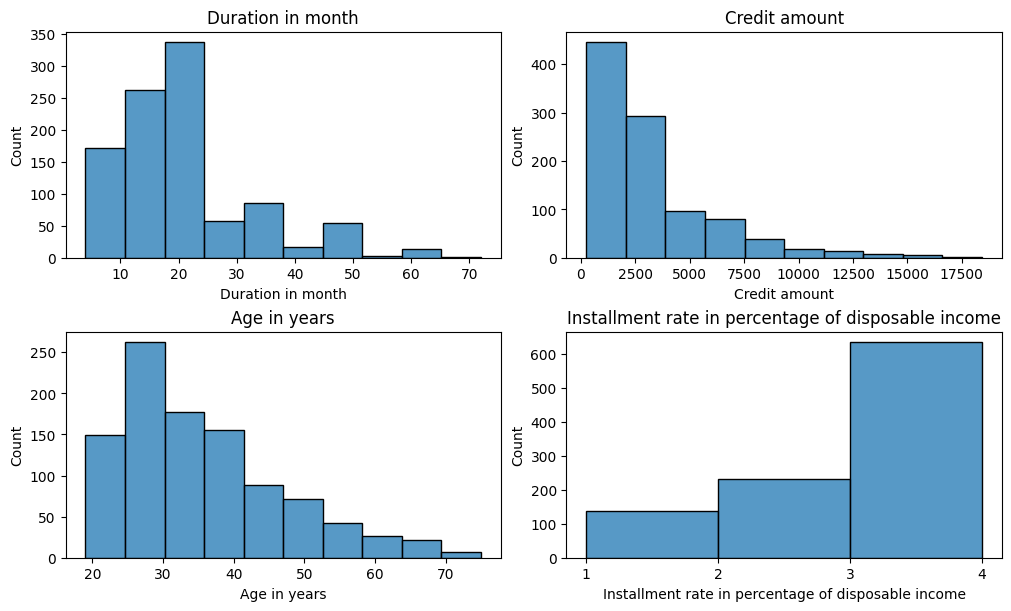

In [95]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6), constrained_layout = True)
# Gráfica 1
sns.histplot(x="Duration in month", data = df, bins = 10, ax = axes[0,0])
axes[0, 0].set_title("Duration in month")
# Gráfica 2
sns.histplot(x="Credit amount", data = df, bins = 10, ax = axes[0,1])
axes[0, 1].set_title("Credit amount")
# Gráfica 3
sns.histplot(x="Age in years", data = df, bins = 10, ax = axes[1,0])
axes[1, 0].set_title("Age in years")
# Gráfica 4
intervalos = np.arange(1, 5, 1)
sns.histplot(x="Installment rate in percentage of disposable income", data = df, bins = intervalos, ax = axes[1,1])
plt.xticks(intervalos)
axes[1, 1].set_title("Installment rate in percentage of disposable income")

plt.show()

Ahora pasemos a analizas las variables categóricas, hay una variable muy importante que es Risk, ya que esta nos indica si los clientes son buenos o malos. Esta es la variable que queremos predicir. Grafiquemos en un digrama de barras el conteo de buenos y malos:

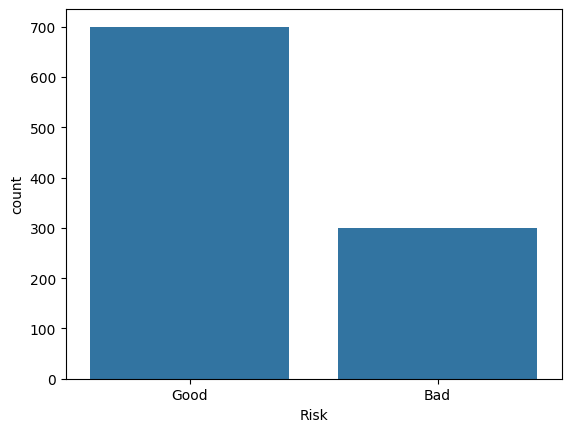

In [141]:
sns.countplot(x="Risk", data = df)
plt.show()

In [142]:
num_buenas = df[df["Risk"]=="Good"]["Risk"].count()
num_malas = df[df["Risk"]=="Bad"]["Risk"].count()
print(f"Porcentaje de personas que si cumplen: %{num_buenas/len(df)*100}")
print(f"Porcentaje de personas no cumplen: %{num_malas/len(df)*100}")

Porcentaje de personas que si cumplen: %70.0
Porcentaje de personas no cumplen: %30.0


Como podemos notar el porcetaje de personas que se cumplen es del 70% y el porcetanje de las que no cumplen es de 30%, es decir, la clase "Bad" es que pequeña con respecto a "Good", por lo tanto, nuestro modelo tiene que tener en cuenta ese desbalance de clases. Para analizar otras variables categóricas podemos realizar gráficos de barras y ver como se distribuyen los conteos en cada categoria. Dibujemos algunas gráficas:

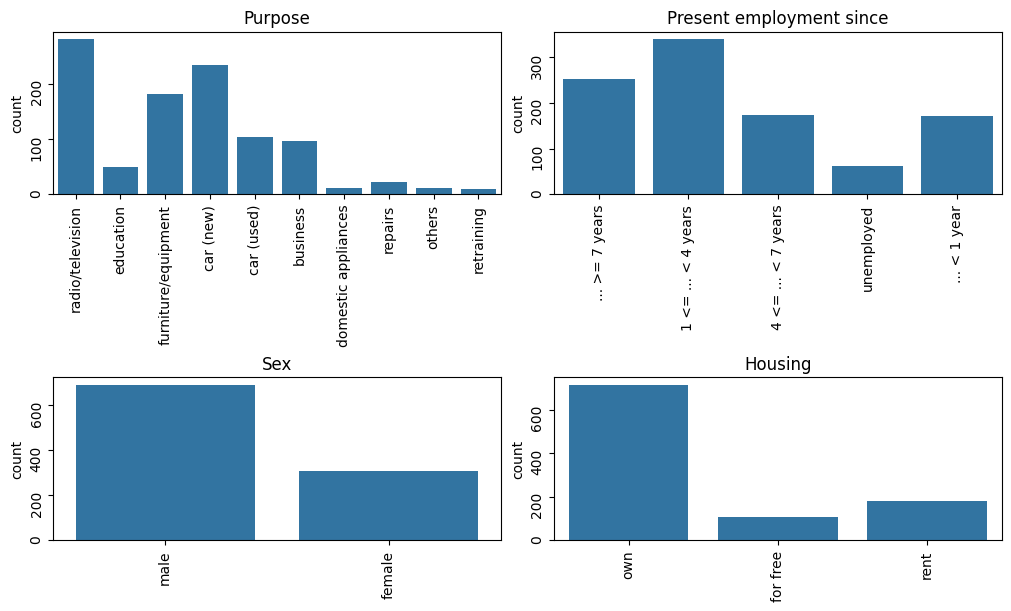

In [113]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6), constrained_layout = True)
#Gráfica 1
sns.countplot(x="Purpose", data = df, ax = axes[0,0])
axes[0,0].tick_params(rotation=90)
axes[0,0].set_title("Purpose")
axes[0,0].set(xlabel="")
#Gráfica 2
sns.countplot(x="Present employment since", data = df, ax = axes[0,1])
axes[0,1].tick_params(rotation=90)
axes[0,1].set_title("Present employment since")
axes[0,1].set(xlabel="")
#Gráfica 3
sns.countplot(x="Sex", data = df, ax = axes[1,0])
axes[1,0].tick_params(rotation=90)
axes[1,0].set_title("Sex")
axes[1,0].set(xlabel="")
#Gráfica 4
sns.countplot(x="Housing", data = df, ax = axes[1,1])
axes[1,1].tick_params(rotation=90)
axes[1,1].set_title("Housing")
axes[1,1].set(xlabel="")

plt.show()

De las gráficas anteriores también podemos sacar conclusiones interesantes, el propósito que aparece con más frecuencia es para adquirir un radio/televisión; el tiempo promedio de empleo es entre 1 y 4 años; hay más clientes hombres que mujeres y finalmente, la mayoría de los clientes tienen casa propia. Grafiquemos otras 4 variables cualitativas:

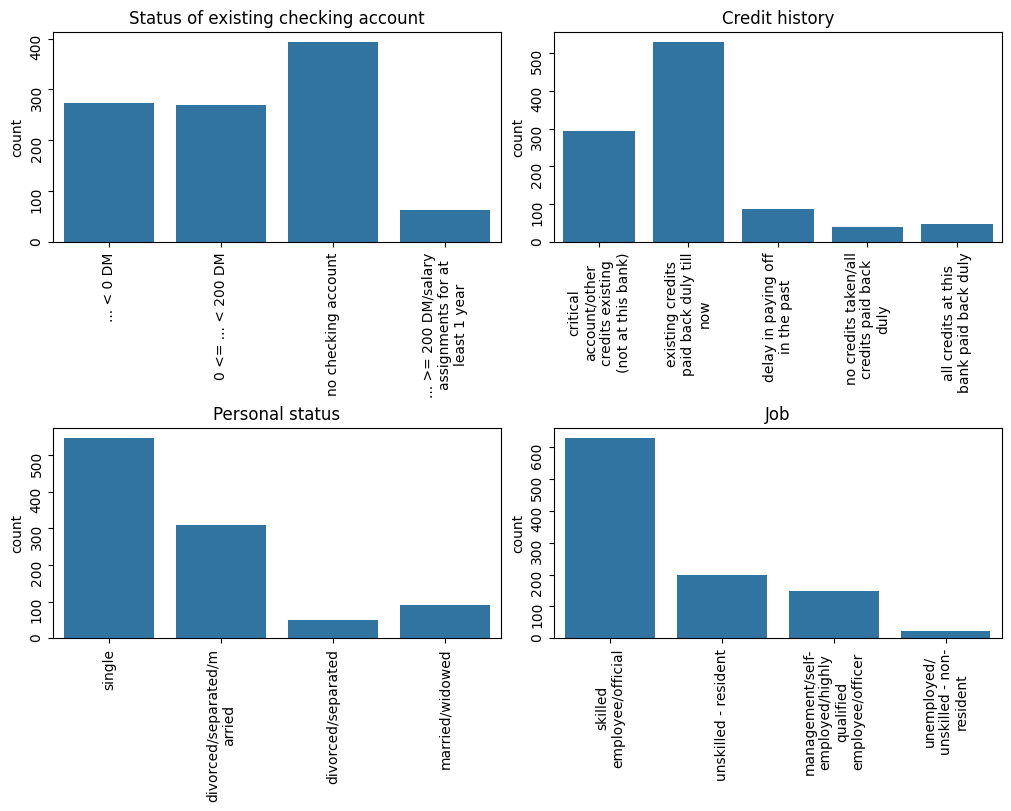

In [137]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), constrained_layout = True)
longitudEtiquetas = 20
#Gráfica 1
df_temp = (df["Status of existing checking account"].apply(lambda x: textwrap.fill(str(x), width=longitudEtiquetas))).to_frame()
sns.countplot(x="Status of existing checking account", data = df_temp, ax = axes[0,0])
axes[0,0].tick_params(rotation=90)
axes[0,0].set_title("Status of existing checking account")
axes[0,0].set(xlabel="")
#Gráfica 2
df_temp = (df["Credit history"].apply(lambda x: textwrap.fill(str(x), width=longitudEtiquetas))).to_frame()
sns.countplot(x="Credit history", data = df_temp, ax = axes[0,1])
axes[0,1].tick_params(rotation=90)
axes[0,1].set_title("Credit history")
axes[0,1].set(xlabel="")
#Gráfica 3
df_temp = (df["Personal status"].apply(lambda x: textwrap.fill(str(x), width=longitudEtiquetas))).to_frame()
sns.countplot(x="Personal status", data = df_temp, ax = axes[1,0])
axes[1,0].tick_params(rotation=90)
axes[1,0].set_title("Personal status")
axes[1,0].set(xlabel="")
#Gráfica 4
df_temp = (df["Job"].apply(lambda x: textwrap.fill(str(x), width=longitudEtiquetas))).to_frame()
sns.countplot(x="Job", data = df_temp, ax = axes[1,1])
axes[1,1].tick_params(rotation=90)
axes[1,1].set_title("Job")
axes[1,1].set(xlabel="")

plt.show()

De las gráficas anteriores también podemos extraer información valiosa, por ejemplo, cerca de 400 clientes no tienen una cuenta corriente en el banco; cerca de 500 clientes tienen créditos existentes reembolsados puntualmente hasta la fecha; poco más de 500 clientes son solteros y poco más de 600 clientes tienen algún empleo. Con esto concluimos el análisis exploratorio de los datos, en las siguientes secciones crearemos nuestro modelo para intentar predecir si un cliente es bueno o malo desde el punto de vista de riesgo crediticio.

# Preparación de los datos para el modelo
Del análisis que hemos hecho anteriormente podemos ver que la mayoria de las variables son no cualitativas y solo tenemos 7 columnas cuantitativas. Los modelos de machine learning solo trabajan con variables numéricas así que usaremos la técnica de one-hot encodig para convertir las columnas cualitativas a columnas con ceros y unos. Por otro lado, también es recomendable reescalar las columnas numéricas para que varien dentro del mismo rango de valores y así evitar que una variable tenga más peso o relevancia que otra. El código es el siguiente:

In [147]:
# Selección de features
X = df.drop(columns=["Risk"])

#Selección de target (variable objetivo)
y = df["Risk"]

# Identificación de features numéricas
features_numericas = X.select_dtypes(include=["int64"]).columns

# Identificación de features categóricas
features_categoricas = X.select_dtypes(include=["str"]).columns

# Definimos una transformación para el preprocesamiento
preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), features_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features_categoricas)
    ]
)

# Separación de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Antes de pasar al entrenamiento del modelo cabe señalar tres cosas importantes acerca de la última linea de código. Primero que estamos usando 80% de los datos para entrenamiento y 20% para realizar pruebas. Segundo, estamos usando una semilla aleatoria para asegurar la reproducibilidad del experimento aleatorio. Tercero, estamos usando el parámetro "stratify" para que tanto en el conjunto de entrenamiento como en el conjunto de pruebas existan proporciones iguales de las clases "Good" y "Bad".

# Regresión logística
El primero modelo que usaremos es el de regresión logística. 

In [148]:
# Definimos un pipeline para asegurar el preprocesamiento y la regresión logística en un solo modelo
model = Pipeline(
    steps=[("preprocesamiento", preprocesamiento),
        ("clasificacion", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Entrenamiento del modelo
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('clasificacion', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Bad','Good']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Status of existing checking account','Duration in month', 'Credit history',...,'Foreign worker','Personal status','Sex']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

Una vez entrenado el modelo podemos proceder a evaluar nuestro modelo en el conjunto de prueba:

In [182]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test.to_numpy(), y_pred))
print("Precision:", precision_score(y_test.to_numpy(), y_pred, pos_label="Bad"))
print("Recall   :", recall_score(y_test.to_numpy(), y_pred, pos_label="Bad"))
print("F1       :", f1_score(y_test.to_numpy(), y_pred, pos_label="Bad"))
print("ROC-AUC  :", roc_auc_score(y_test.to_numpy(), y_prob))

Accuracy : 0.695
Precision: 0.4909090909090909
Recall   : 0.45
F1       : 0.46956521739130436
ROC-AUC  : 0.7591666666666668


Como podmeo ver nuestro modelo tiene métricas bastante buenas, en particular el valor ROC-AUC que evalúa la capacidad del modelo para discriminar entre clientes de riesgo y no riesgo. tiene un valor alto. Para comprender mejor como está prediciendo nuestro modelo en el conjunto de test, visualicemos la matriz de confusión:

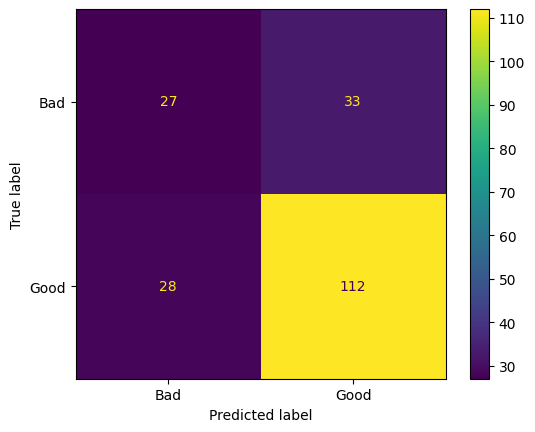

In [186]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

La matriz de confusión mostrada anteriormente se puede leer de la siguiente manera:
* 27 personas en la categoría "Bad" se etiquetaron correctamente como "Bad"
* 33 personas en la categoría "Bad" se etiquedaron incorrectamente como "Good" (error tipo I)
* 112 personas en la categoria "Good" se etiquetaron correctamente como "Good"
* 28 personas en la categoria "Good" se etiquedaron incorrectamente como "Bad" (error tipo II)

Alternativamente podemos resumir la información anterior de la siguiente manera:
$$TP=27$$
$$TN=112$$
$$FP=33$$
$$FP=28$$
Donde $TP$, $TN$, $FP$ y $FN$ hacen referencia a los verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos, respectivamente. Recordemos que en nuestro caso, la categoría positiva es "Bad".

# Referencias
Dua, D., & Graff, C. (s.f.). Statlog (German credit data) [Conjunto de datos]. UCI Machine Learning Repository. Recuperado el 10 de agosto de 2026, de https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data